# ![Netflix Logo](https://upload.wikimedia.org/wikipedia/commons/0/08/Netflix_2015_logo.svg) 
# Analyse du catalogue Netflix


## Objectif du projet
Analyser la composition du catalogue Netflix

Comparer films vs séries

Identifier les pays producteurs principaux

Étudier les classifications d'âge

Cartographier genres et réalisateurs

Visualiser les données pour prise de décision


Notebook préparé pour Manal.

In [29]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

## 1) Chargement des données

In [31]:
df = pd.read_csv("netflix_titles.csv")
df.shape, df.columns.tolist()

((8807, 12),
 ['show_id',
  'type',
  'title',
  'director',
  'cast',
  'country',
  'date_added',
  'release_year',
  'rating',
  'duration',
  'listed_in',
  'description'])

## 2) Aperçu des données

In [3]:
df_clean = df.copy()

# Remplacer les NaN par 'Unknown'
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


## 3) Informations générales et valeurs manquantes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isna().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## 4) Nettoyage et préparation du dataset

In [6]:
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Nombre de directeurs par entrée
df['director_count'] = df['director'].fillna('').apply(lambda x: 0 if x == '' else len(x.split(',')))

## 5) Répartition Movies vs TV Shows

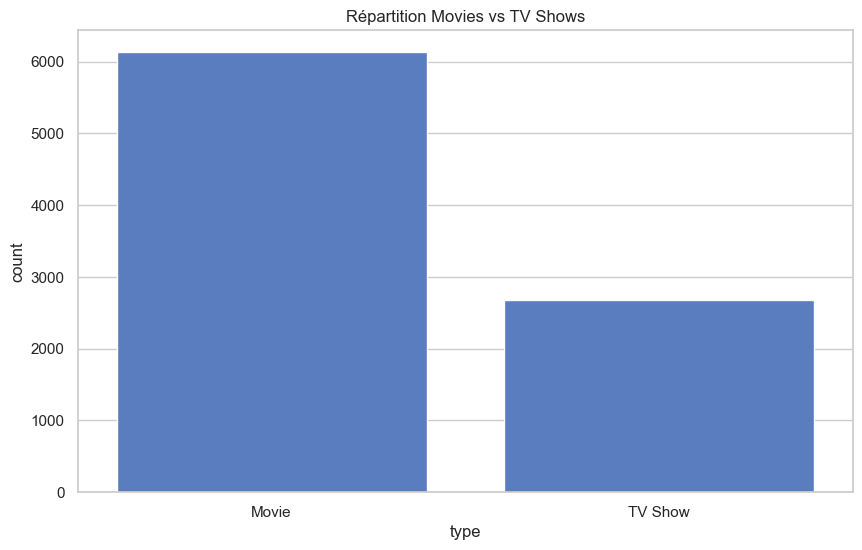

In [7]:
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title("Répartition Movies vs TV Shows")
plt.show()

## 6) Nombre de titres ajoutés par année

In [9]:
import plotly.express as px

# Assure-toi que yearly est défini correctement
yearly = df.dropna(subset=['date_added']).groupby('release_year').size().reset_index(name='count')

# Utilise les noms exacts des colonnes
fig = px.bar(yearly, x='release_year', y='count', title='Titres ajoutés par année')
fig.show()


## 7) Durée des films et séries

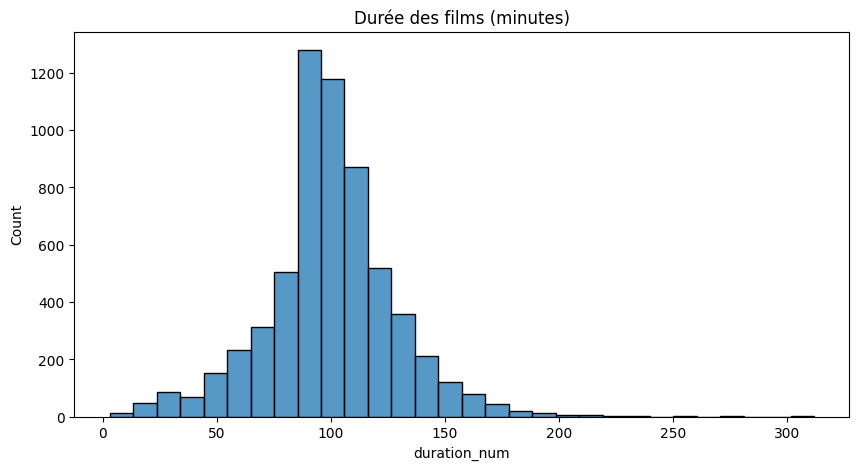

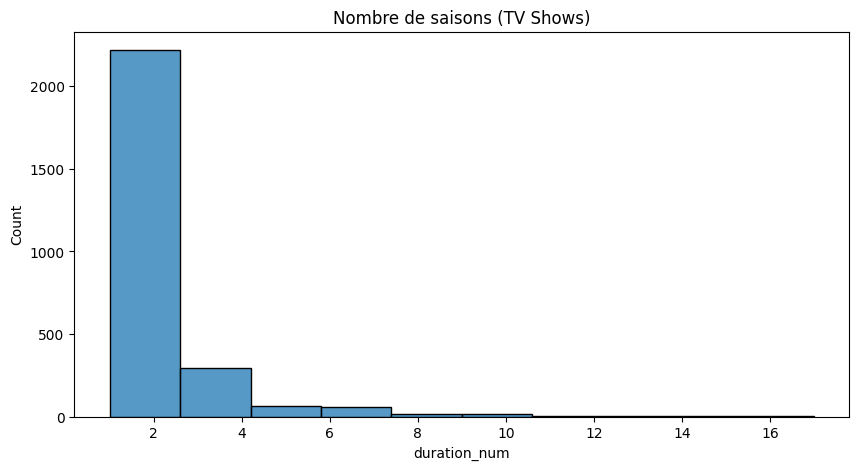

In [10]:
df['duration_str'] = df['duration'].astype(str)
df['duration_num'] = df['duration_str'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration_str'].str.extract(r'([A-Za-z]+)')

movies = df[df['duration_unit'].str.contains('min', na=False)]
shows = df[df['duration_unit'].str.contains('Season', na=False)]

plt.figure(figsize=(10,5))
sns.histplot(movies['duration_num'], bins=30)
plt.title("Durée des films (minutes)")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(shows['duration_num'], bins=10)
plt.title("Nombre de saisons (TV Shows)")
plt.show()

## 8) Top catégories, pays et acteurs

In [11]:
from collections import Counter

def explode_counts(series):
    counter = Counter()
    for item in series.dropna():
        parts = [p.strip() for p in str(item).split(',') if p.strip()]
        counter.update(parts)
    return pd.Series(counter).sort_values(ascending=False)

top_genres = explode_counts(df['listed_in']).head(15)
top_countries = explode_counts(df['country']).head(15)

top_genres, top_countries

(International Movies        2752
 Dramas                      2427
 Comedies                    1674
 International TV Shows      1351
 Documentaries                869
 Action & Adventure           859
 TV Dramas                    763
 Independent Movies           756
 Children & Family Movies     641
 Romantic Movies              616
 TV Comedies                  581
 Thrillers                    577
 Crime TV Shows               470
 Kids' TV                     451
 Docuseries                   395
 dtype: int64,
 United States     3690
 India             1046
 United Kingdom     806
 Canada             445
 France             393
 Japan              318
 Spain              232
 South Korea        231
 Germany            226
 Mexico             169
 China              162
 Australia          160
 Egypt              117
 Turkey             113
 Hong Kong          105
 dtype: int64)

## 9) Quelques requêtes utiles

In [12]:
# Films de 2019
films_2019 = df[(df['type'] == 'Movie') & (df['release_year'] == 2019)]
films_2019[['title', 'director', 'release_year']].head(10)

,title,director,release_year
90,Paradise Hills,Alice Waddington,2019
334,Five Feet Apart,Justin Baldoni,2019
348,Poms,Zara Hayes,2019
378,Fantastic Fungi,Louie Schwartzberg,2019
389,The Operative,Yuval Adler,2019
418,Chhota Bheem Ka Roosi Romanch,"Arpan Sarkar, Shyamal Chaulia",2019
427,Wannabe Courageous,Mahmoud Karim,2019
461,The Unknown Saint,Alaa Eddine Aljem,2019
462,This Changes Everything,Tom Donahue,2019
469,American Woman,Semi Chellas,2019


In [13]:
# Séries produites au Maroc
maroc = df[df['country'].str.contains('Morocco', na=False)]
maroc[['title', 'type', 'release_year']].head(10)

,title,type,release_year
5260,Much Loved,Movie,2015
6691,Empire of Scents,Movie,2014
7676,Operation Red Sea,Movie,2018
7811,Queen of the Desert,Movie,2015
8326,The Gospel of John,Movie,2014
8327,The Gospel of Luke,Movie,2015


In [14]:
# Titres d'un acteur spécifique
actor = "Tom Hanks"
df[df['cast'].str.contains(actor, na=False)][['title', 'type', 'release_year']].head(10)

,title,type,release_year
329,Catch Me If You Can,Movie,2002
1610,Angels & Demons,Movie,2009
1624,The Da Vinci Code,Movie,2006
6501,Cloud Atlas,Movie,2012
6589,Defying the Nazis: The Sharps' War,Movie,2016
7735,Philadelphia,Movie,1993
7949,Saving Mr. Banks,Movie,2013
8461,The Polar Express,Movie,2004


## 10) Sauvegarde du dataset nettoyé

In [15]:
df.to_csv('netflix_titles_clean.csv', index=False)
print("Fichier nettoyé sauvegardé : netflix_titles_clean.csv")

Fichier nettoyé sauvegardé : netflix_titles_clean.csv


# Intrerprétation des Résultats

## 1. Ratio Films vs Séries TV sur Netflix

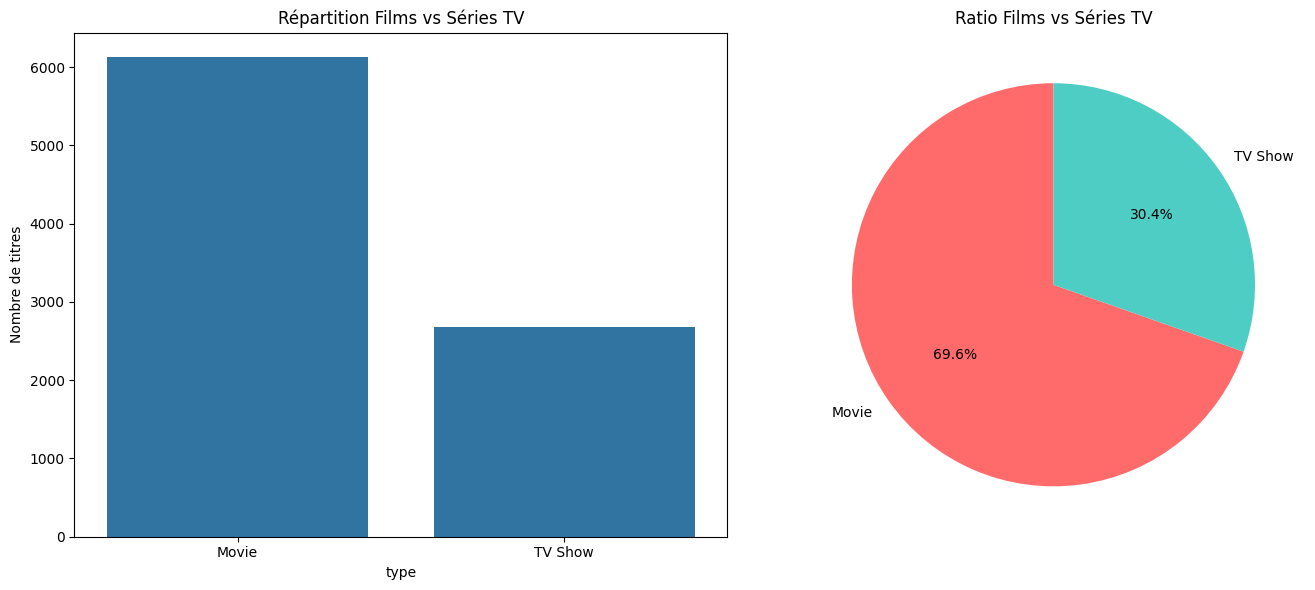

Ratio Films/Séries: 2.29 (soit environ 2.3 films pour 1 série)
Nombre total de films: 6131
Nombre total de séries: 2676
Pourcentage de films: 69.6%
Pourcentage de séries: 30.4%


In [17]:
# Visualisation du ratio Films vs Séries TV
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Diagramme en barres
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax1)
ax1.set_title("Répartition Films vs Séries TV")
ax1.set_ylabel("Nombre de titres")

# Diagramme circulaire
colors = ['#ff6b6b', '#4ecdc4']
ax2.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax2.set_title("Ratio Films vs Séries TV")

plt.tight_layout()
plt.show()

# Calcul du ratio
ratio_movies_shows = type_counts['Movie'] / type_counts['TV Show']
print(f"Ratio Films/Séries: {ratio_movies_shows:.2f} (soit environ {ratio_movies_shows:.1f} films pour 1 série)")
print(f"Nombre total de films: {type_counts['Movie']}")
print(f"Nombre total de séries: {type_counts['TV Show']}")
print(f"Pourcentage de films: {(type_counts['Movie']/len(df)*100):.1f}%")
print(f"Pourcentage de séries: {(type_counts['TV Show']/len(df)*100):.1f}%")

## 2. Pays produisant le plus de contenu

C:\Users\hp\AppData\Local\Temp\ipykernel_9692\1406318264.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




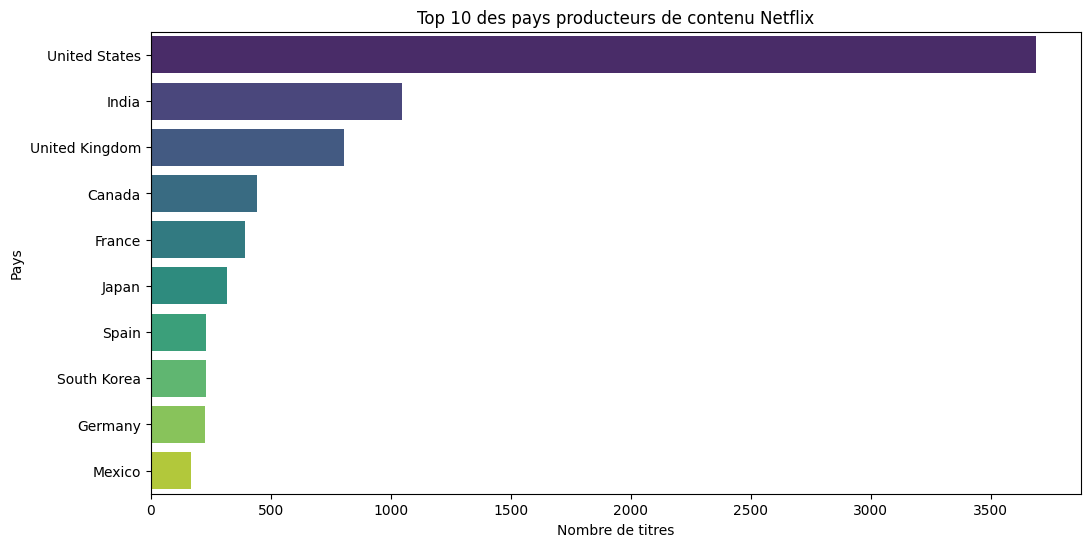

Top 10 des pays producteurs:
1. United States: 3690 titres (41.9%)
2. India: 1046 titres (11.9%)
3. United Kingdom: 806 titres (9.2%)
4. Canada: 445 titres (5.1%)
5. France: 393 titres (4.5%)
6. Japan: 318 titres (3.6%)
7. Spain: 232 titres (2.6%)
8. South Korea: 231 titres (2.6%)
9. Germany: 226 titres (2.6%)
10. Mexico: 169 titres (1.9%)


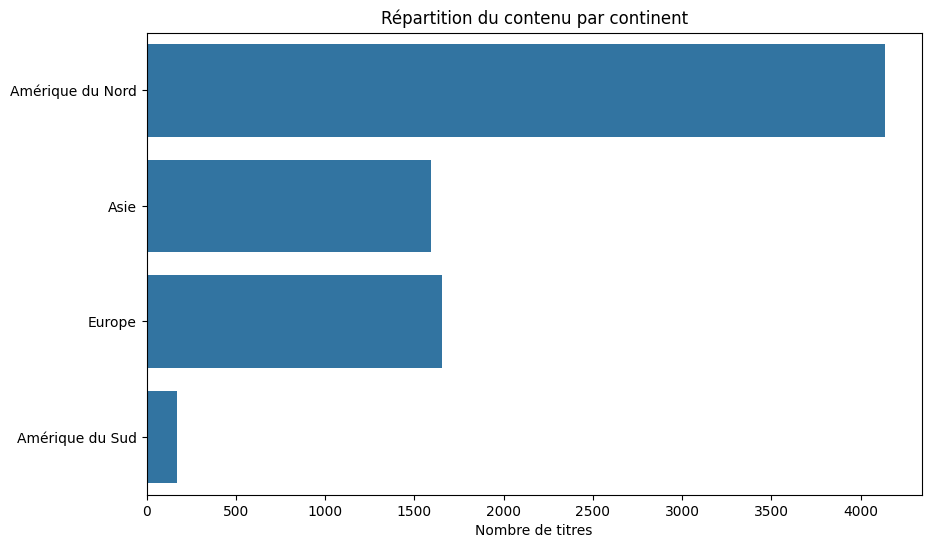

In [18]:
# Top 10 des pays producteurs
plt.figure(figsize=(12, 6))
top_10_countries = top_countries.head(10)
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='viridis')
plt.title("Top 10 des pays producteurs de contenu Netflix")
plt.xlabel("Nombre de titres")
plt.ylabel("Pays")
plt.show()

# Affichage détaillé
print("Top 10 des pays producteurs:")
for i, (country, count) in enumerate(top_10_countries.items(), 1):
    pourcentage = (count / len(df)) * 100
    print(f"{i}. {country}: {count} titres ({pourcentage:.1f}%)")

# Répartition par continent (approximative)
continent_mapping = {
    'United States': 'Amérique du Nord',
    'Canada': 'Amérique du Nord',
    'India': 'Asie',
    'United Kingdom': 'Europe',
    'France': 'Europe',
    'Japan': 'Asie',
    'Spain': 'Europe',
    'South Korea': 'Asie',
    'Germany': 'Europe',
    'Mexico': 'Amérique du Sud'
}

continent_counts = Counter()
for country in df['country'].dropna():
    countries = [c.strip() for c in str(country).split(',')]
    for c in countries:
        if c in continent_mapping:
            continent_counts[continent_mapping[c]] += 1

plt.figure(figsize=(10, 6))
sns.barplot(x=list(continent_counts.values()), y=list(continent_counts.keys()))
plt.title("Répartition du contenu par continent")
plt.xlabel("Nombre de titres")
plt.show()

## 3. Évolution du nombre de contenus ajoutés au fil des années

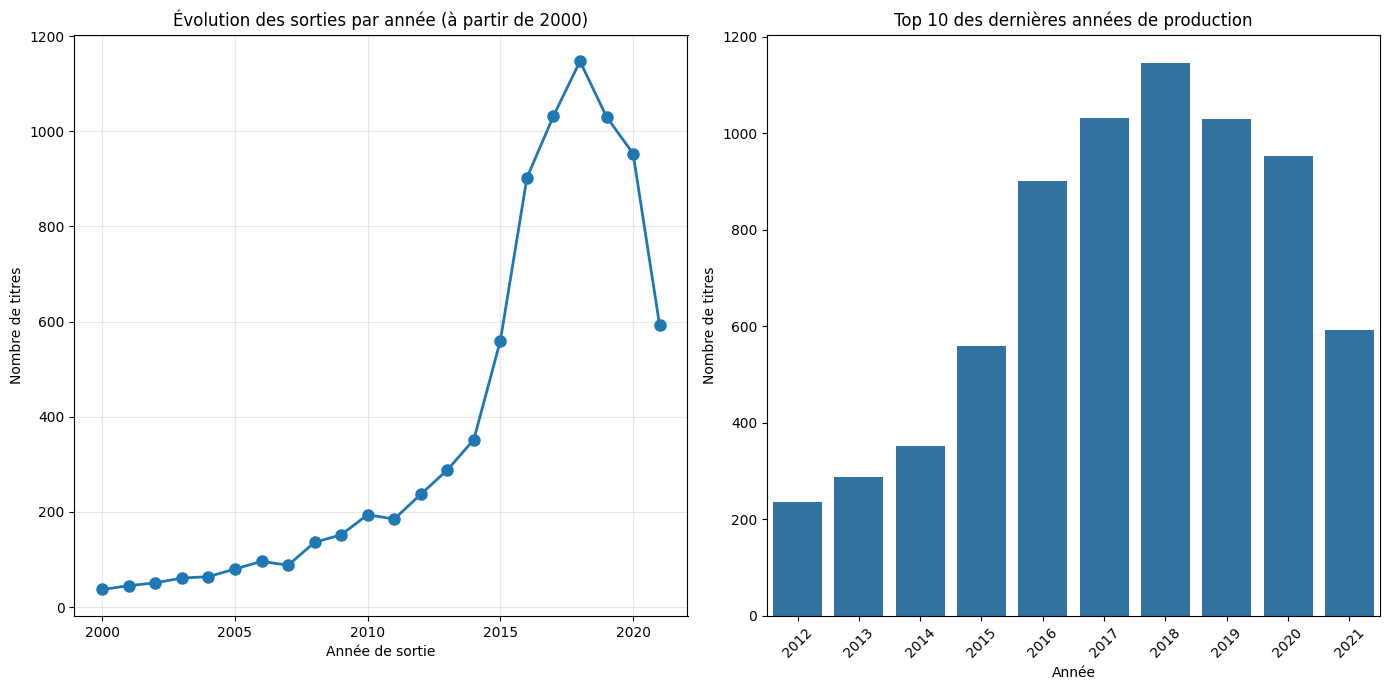

Analyse des tendances annuelles:
Année avec le plus de productions: 2018 (1147 titres)
Année avec le moins de productions: 1925 (1 titres)
De 2010 à 2011: -4.6% de croissance
De 2011 à 2012: 28.1% de croissance
De 2012 à 2013: 21.5% de croissance
De 2013 à 2014: 22.2% de croissance
De 2014 à 2015: 59.1% de croissance
De 2015 à 2016: 61.1% de croissance
De 2016 à 2017: 14.4% de croissance
De 2017 à 2018: 11.1% de croissance
De 2018 à 2019: -10.2% de croissance
De 2019 à 2020: -7.5% de croissance
De 2020 à 2021: -37.9% de croissance


In [19]:
# Evolution plus détaillée
plt.figure(figsize=(14, 7))

# Contenu total par année
yearly_total = df['release_year'].value_counts().sort_index()

# Filtrer les années récentes (à partir de 2000)
yearly_total_recent = yearly_total[yearly_total.index >= 2000]

# Créer un graphique avec tendance
plt.subplot(1, 2, 1)
plt.plot(yearly_total_recent.index, yearly_total_recent.values, marker='o', linewidth=2, markersize=8)
plt.title("Évolution des sorties par année (à partir de 2000)")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de titres")
plt.grid(True, alpha=0.3)

# Graphique en barres pour les 10 dernières années
plt.subplot(1, 2, 2)
last_10_years = yearly_total.sort_index(ascending=False).head(10).sort_index()
sns.barplot(x=last_10_years.index, y=last_10_years.values)
plt.title("Top 10 des dernières années de production")
plt.xlabel("Année")
plt.ylabel("Nombre de titres")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Analyse des tendances
print("Analyse des tendances annuelles:")
print(f"Année avec le plus de productions: {yearly_total.idxmax()} ({yearly_total.max()} titres)")
print(f"Année avec le moins de productions: {yearly_total.idxmin()} ({yearly_total.min()} titres)")

# Taux de croissance
recent_years = sorted([y for y in yearly_total.index if y >= 2010])
for i in range(1, len(recent_years)):
    current = yearly_total[recent_years[i]]
    previous = yearly_total[recent_years[i-1]]
    if previous > 0:
        growth = ((current - previous) / previous) * 100
        print(f"De {recent_years[i-1]} à {recent_years[i]}: {growth:.1f}% de croissance")

## 4. Classifications les plus courantes

C:\Users\hp\AppData\Local\Temp\ipykernel_9692\3130570955.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




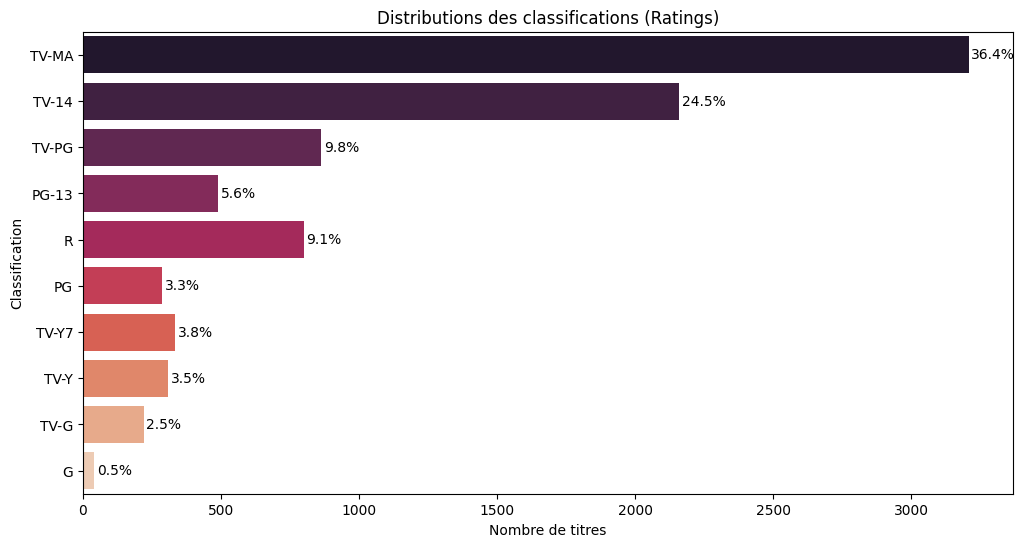


Analyse des ratings par type de contenu:

Top 5 ratings pour les Movies:
  TV-MA: 2062 (33.6%)
  TV-14: 1427 (23.3%)
  R: 797 (13.0%)
  TV-PG: 540 (8.8%)
  PG-13: 490 (8.0%)

Top 5 ratings pour les TV Shows:
  TV-MA: 1145 (42.8%)
  TV-14: 733 (27.4%)
  TV-PG: 323 (12.1%)
  TV-Y7: 195 (7.3%)
  TV-Y: 176 (6.6%)


In [20]:
# Analyse des ratings
plt.figure(figsize=(12, 6))

# Top 15 des ratings
rating_counts = df['rating'].value_counts().head(15)

# Créer une palette de couleurs significative
rating_order = ['TV-MA', 'TV-14', 'TV-PG', 'PG-13', 'R', 'PG', 'TV-Y7', 'TV-Y', 'TV-G', 'G']
available_order = [r for r in rating_order if r in rating_counts.index]

sns.barplot(x=rating_counts.loc[available_order].values, 
            y=rating_counts.loc[available_order].index,
            palette='rocket')
plt.title("Distributions des classifications (Ratings)")
plt.xlabel("Nombre de titres")
plt.ylabel("Classification")

# Ajouter les pourcentages
total = len(df.dropna(subset=['rating']))
for i, (rating, count) in enumerate(rating_counts.loc[available_order].items()):
    percentage = (count / total) * 100
    plt.text(count + 10, i, f'{percentage:.1f}%', va='center')

plt.show()

# Analyse par type de contenu
print("\nAnalyse des ratings par type de contenu:")
print("=" * 50)

for content_type in ['Movie', 'TV Show']:
    subset = df[df['type'] == content_type]
    ratings = subset['rating'].value_counts().head(5)
    print(f"\nTop 5 ratings pour les {content_type}s:")
    for rating, count in ratings.items():
        percentage = (count / len(subset)) * 100
        print(f"  {rating}: {count} ({percentage:.1f}%)")

## 5. Top 10 des réalisateurs avec le plus de contenu

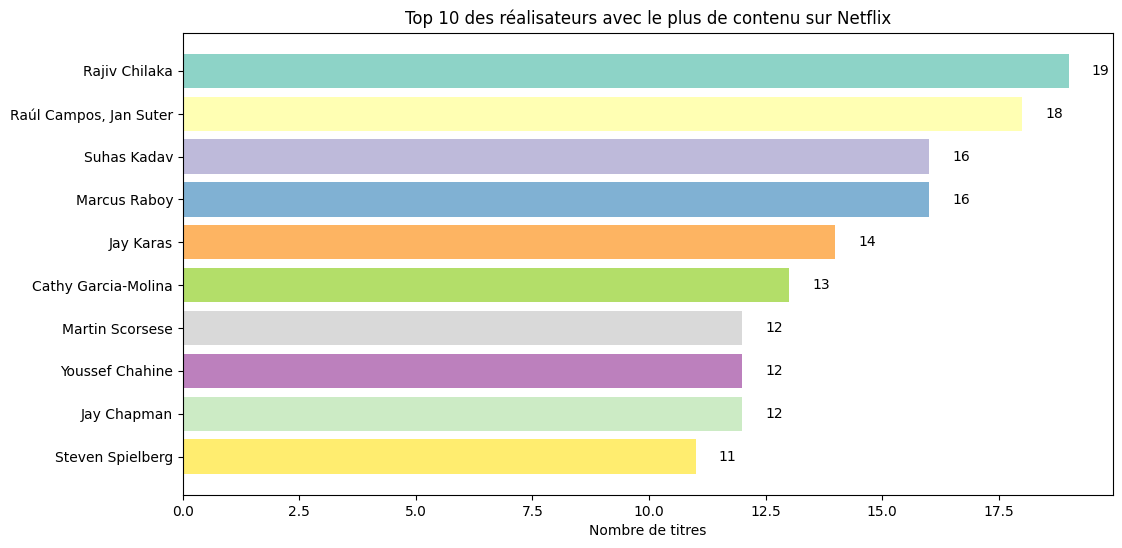

Top 10 des réalisateurs:

1. Rajiv Chilaka:
   Total: 19 titres
   Films: 19
   Séries: 0
   Période: 2009 - 2018

2. Raúl Campos, Jan Suter:
   Total: 18 titres
   Films: 18
   Séries: 0
   Période: 2016 - 2018

3. Suhas Kadav:
   Total: 16 titres
   Films: 16
   Séries: 0
   Période: 2013 - 2019

4. Marcus Raboy:
   Total: 16 titres
   Films: 15
   Séries: 1
   Période: 2012 - 2020

5. Jay Karas:
   Total: 14 titres
   Films: 14
   Séries: 0
   Période: 2012 - 2020

6. Cathy Garcia-Molina:
   Total: 13 titres
   Films: 13
   Séries: 0
   Période: 2008 - 2019

7. Martin Scorsese:
   Total: 12 titres
   Films: 12
   Séries: 0
   Période: 1967 - 2019

8. Youssef Chahine:
   Total: 12 titres
   Films: 12
   Séries: 0
   Période: 1954 - 1999

9. Jay Chapman:
   Total: 12 titres
   Films: 12
   Séries: 0
   Période: 2012 - 2018

10. Steven Spielberg:
   Total: 11 titres
   Films: 11
   Séries: 0
   Période: 1975 - 2016


Top 10 des réalisateurs (sans 'Unknown'):

1. Rajiv Chilaka:
   Total

In [28]:
# Top 10 des réalisateurs
import numpy as np  # Ajoutez cette ligne

top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(12, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(top_directors)))
bars = plt.barh(range(len(top_directors)), top_directors.values, color=colors)
plt.yticks(range(len(top_directors)), top_directors.index)
plt.gca().invert_yaxis()  # Inverser l'ordre pour avoir le plus grand en haut
plt.title("Top 10 des réalisateurs avec le plus de contenu sur Netflix")
plt.xlabel("Nombre de titres")

# Ajouter les valeurs sur les barres
for i, (director, count) in enumerate(top_directors.items()):
    plt.text(count + 0.5, i, str(count), va='center')

plt.show()

# Analyse détaillée
print("Top 10 des réalisateurs:")
print("=" * 50)
for i, (director, count) in enumerate(top_directors.items(), 1):
    # Exclure 'Unknown' de l'analyse détaillée
    if director != 'Unknown':
        # Filtrer les réalisations par type
        director_movies = len(df[(df['director'] == director) & (df['type'] == 'Movie')])
        director_shows = len(df[(df['director'] == director) & (df['type'] == 'TV Show')])
        
        print(f"\n{i}. {director}:")
        print(f"   Total: {count} titres")
        print(f"   Films: {director_movies}")
        print(f"   Séries: {director_shows}")
        
        # Années de production
        years = df[df['director'] == director]['release_year'].unique()
        if len(years) > 0:
            print(f"   Période: {min(years)} - {max(years)}")
    else:
        print(f"\n{i}. {director}: {count} titres (réalisateur inconnu)")

# Version alternative si 'Unknown' est en tête
print("\n\nTop 10 des réalisateurs (sans 'Unknown'):")
print("=" * 50)
top_directors_no_unknown = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

for i, (director, count) in enumerate(top_directors_no_unknown.items(), 1):
    # Filtrer les réalisations par type
    director_movies = len(df[(df['director'] == director) & (df['type'] == 'Movie')])
    director_shows = len(df[(df['director'] == director) & (df['type'] == 'TV Show')])
    
    print(f"\n{i}. {director}:")
    print(f"   Total: {count} titres")
    print(f"   Films: {director_movies}")
    print(f"   Séries: {director_shows}")
    
    # Années de production
    years = df[df['director'] == director]['release_year'].unique()
    if len(years) > 0:
        print(f"   Période: {min(years)} - {max(years)}")
    
    # Genres principaux
    genres = explode_counts(df[df['director'] == director]['listed_in']).head(3)
    if len(genres) > 0:
        print(f"   Genres principaux: {', '.join(genres.index.tolist())}")

## 6. Distribution de la durée des films

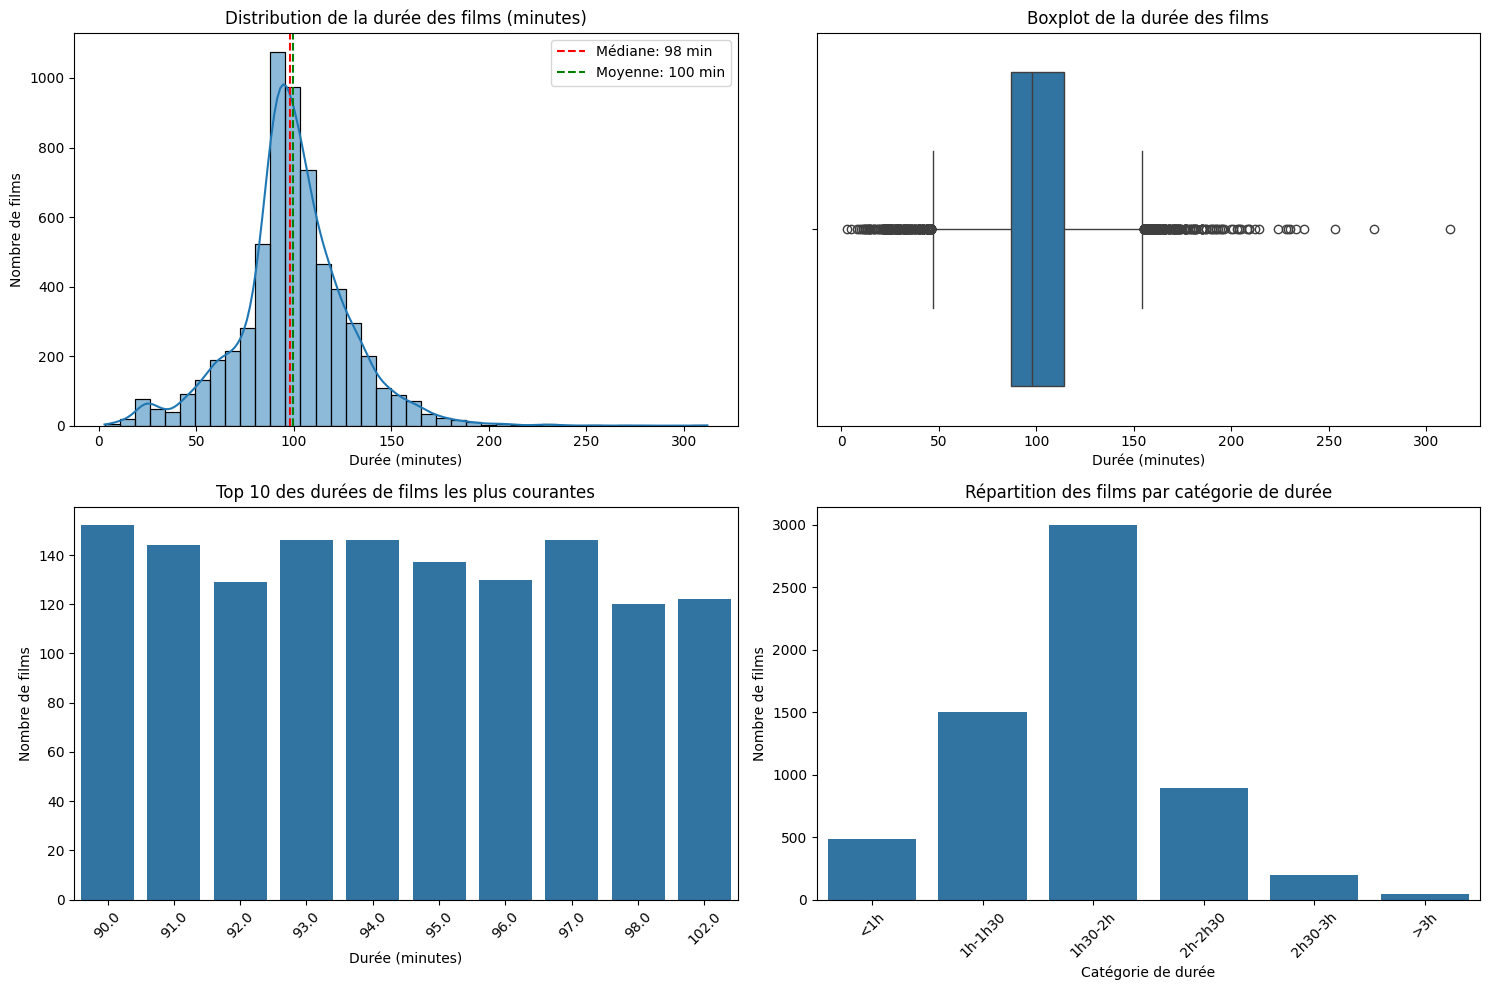

Statistiques sur la durée des films:
Moyenne: 99.6 minutes
Médiane: 98 minutes
Minimum: 3 minutes
Maximum: 312 minutes
Écart-type: 28.3 minutes
1er quartile: 87 minutes
3ème quartile: 114 minutes


In [22]:
# Analyse approfondie de la durée des films
plt.figure(figsize=(15, 10))

# Histogramme avec courbe de densité
plt.subplot(2, 2, 1)
sns.histplot(movies['duration_num'], bins=40, kde=True)
plt.title("Distribution de la durée des films (minutes)")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")
plt.axvline(movies['duration_num'].median(), color='red', linestyle='--', 
            label=f'Médiane: {movies["duration_num"].median():.0f} min')
plt.axvline(movies['duration_num'].mean(), color='green', linestyle='--', 
            label=f'Moyenne: {movies["duration_num"].mean():.0f} min')
plt.legend()

# Boxplot
plt.subplot(2, 2, 2)
sns.boxplot(x=movies['duration_num'])
plt.title("Boxplot de la durée des films")
plt.xlabel("Durée (minutes)")

# Top 10 des durées les plus fréquentes
plt.subplot(2, 2, 3)
common_durations = movies['duration_num'].value_counts().head(10)
sns.barplot(x=common_durations.index, y=common_durations.values)
plt.title("Top 10 des durées de films les plus courantes")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")
plt.xticks(rotation=45)

# Répartition par catégories de durée
plt.subplot(2, 2, 4)
duration_categories = pd.cut(movies['duration_num'], 
                            bins=[0, 60, 90, 120, 150, 180, 300],
                            labels=['<1h', '1h-1h30', '1h30-2h', '2h-2h30', '2h30-3h', '>3h'])
category_counts = duration_categories.value_counts().sort_index()
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title("Répartition des films par catégorie de durée")
plt.xlabel("Catégorie de durée")
plt.ylabel("Nombre de films")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Statistiques descriptives
print("Statistiques sur la durée des films:")
print("=" * 50)
print(f"Moyenne: {movies['duration_num'].mean():.1f} minutes")
print(f"Médiane: {movies['duration_num'].median():.0f} minutes")
print(f"Minimum: {movies['duration_num'].min():.0f} minutes")
print(f"Maximum: {movies['duration_num'].max():.0f} minutes")
print(f"Écart-type: {movies['duration_num'].std():.1f} minutes")
print(f"1er quartile: {movies['duration_num'].quantile(0.25):.0f} minutes")
print(f"3ème quartile: {movies['duration_num'].quantile(0.75):.0f} minutes")

## 7. Genres les plus populaires

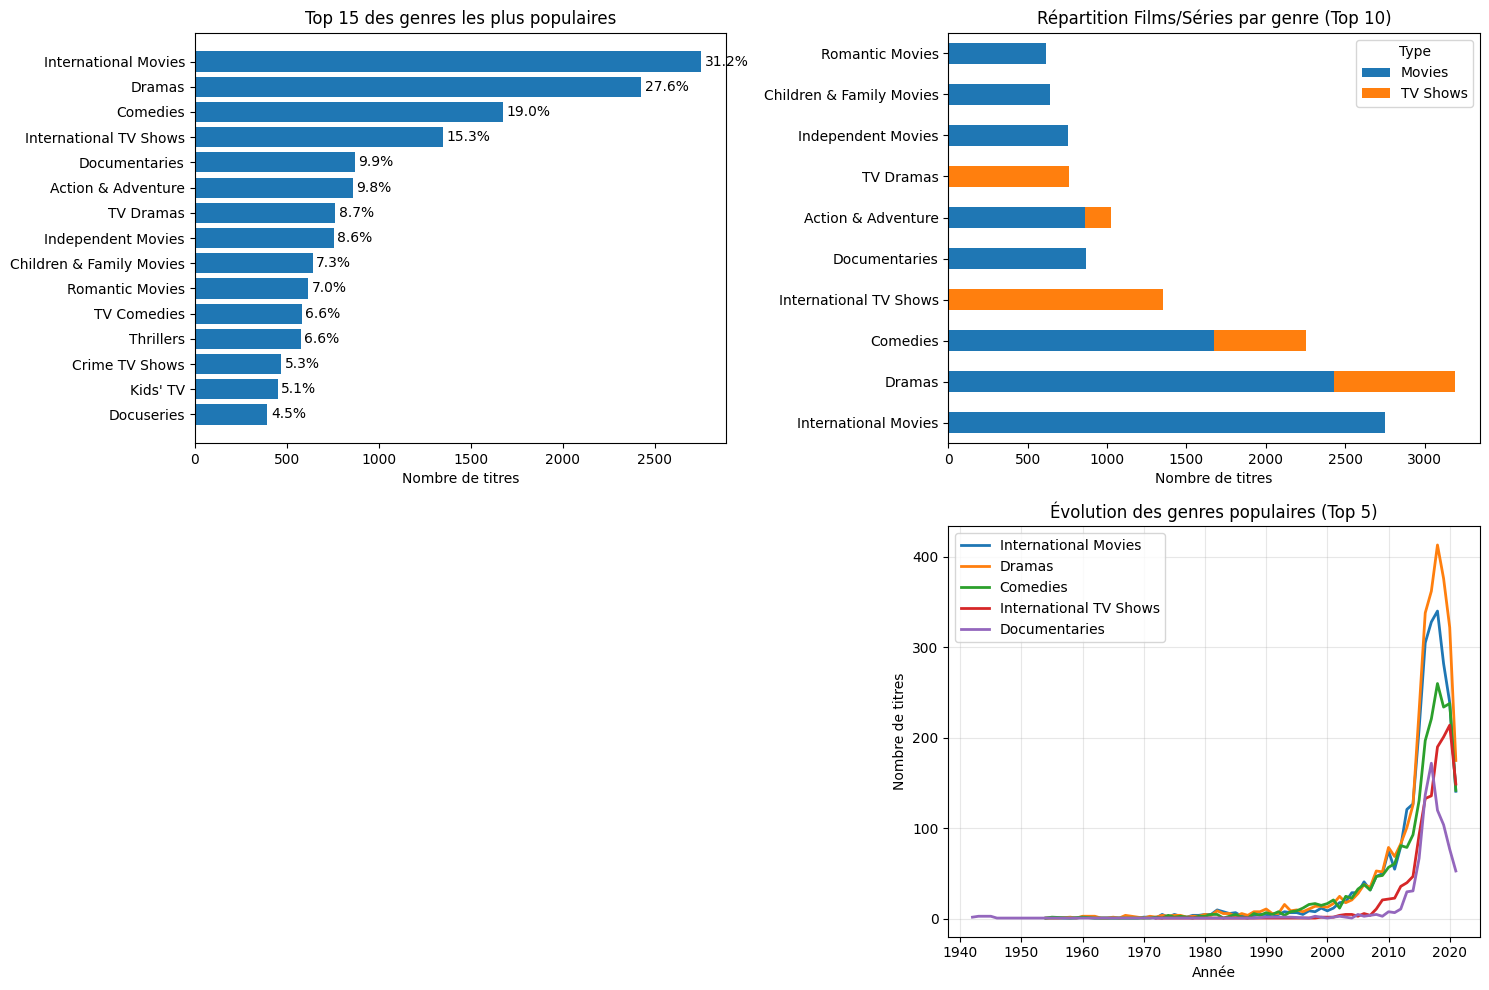

Analyse des combinaisons de genres:

Top 10 des combinaisons de genres:
1. Dramas, International Movies: 362 titres
2. Documentaries: 359 titres
3. Stand-Up Comedy: 334 titres
4. Comedies, Dramas, International Movies: 274 titres
5. Dramas, Independent Movies, International Movies: 252 titres
6. Kids' TV: 220 titres
7. Children & Family Movies: 215 titres
8. Children & Family Movies, Comedies: 201 titres
9. Documentaries, International Movies: 186 titres
10. Dramas, International Movies, Romantic Movies: 180 titres


In [25]:
# Analyse approfondie des genres
plt.figure(figsize=(15, 10))

# Top 15 des genres
plt.subplot(2, 2, 1)
top_15_genres = top_genres.head(15)
bars = plt.barh(range(len(top_15_genres)), top_15_genres.values)
plt.yticks(range(len(top_15_genres)), top_15_genres.index)
plt.gca().invert_yaxis()
plt.title("Top 15 des genres les plus populaires")
plt.xlabel("Nombre de titres")

# Ajouter les pourcentages
total_titles = len(df)
for i, (genre, count) in enumerate(top_15_genres.items()):
    percentage = (count / total_titles) * 100
    plt.text(count + 20, i, f'{percentage:.1f}%', va='center')

# Répartition par type de contenu
plt.subplot(2, 2, 2)
genres_by_type = {}
for genre in top_genres.head(10).index:
    movies_count = len(df[(df['listed_in'].str.contains(genre, na=False)) & (df['type'] == 'Movie')])
    shows_count = len(df[(df['listed_in'].str.contains(genre, na=False)) & (df['type'] == 'TV Show')])
    genres_by_type[genre] = {'Movies': movies_count, 'TV Shows': shows_count}

genres_df = pd.DataFrame(genres_by_type).T
genres_df.plot(kind='barh', stacked=True, ax=plt.gca())
plt.title("Répartition Films/Séries par genre (Top 10)")
plt.xlabel("Nombre de titres")
plt.legend(title='Type')



# Créer une chaîne de tous les genres
all_genres = ' '.join(df['listed_in'].dropna().astype(str))
all_genres = all_genres.replace(',', ' ')



# Évolution des genres populaires au fil du temps
plt.subplot(2, 2, 4)
top_5_genres = top_genres.head(5).index
for genre in top_5_genres:
    genre_years = df[df['listed_in'].str.contains(genre, na=False)]['release_year'].value_counts().sort_index()
    plt.plot(genre_years.index, genre_years.values, label=genre, linewidth=2)

plt.title("Évolution des genres populaires (Top 5)")
plt.xlabel("Année")
plt.ylabel("Nombre de titres")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse des combinaisons de genres
print("Analyse des combinaisons de genres:")
print("=" * 50)

# Compter les combinaisons de genres
genre_combinations = df['listed_in'].dropna().apply(lambda x: tuple(sorted([g.strip() for g in str(x).split(',')])))
top_combinations = genre_combinations.value_counts().head(10)

print("\nTop 10 des combinaisons de genres:")
for i, (combo, count) in enumerate(top_combinations.items(), 1):
    print(f"{i}. {', '.join(combo)}: {count} titres")

## 8. Synthèse globale

In [26]:
# Tableau récapitulatif
print("SYNTHÈSE GLOBALE DE L'ANALYSE NETFLIX")
print("=" * 60)

summary_data = {
    'Métrique': [
        'Total des titres',
        'Pourcentage de Films',
        'Pourcentage de Séries',
        'Ratio Films/Séries',
        'Pays leader',
        'Rating le plus courant',
        'Durée moyenne des films',
        'Genre le plus populaire',
        'Année de production la plus active',
        'Top réalisateur'
    ],
    'Valeur': [
        f"{len(df):,}",
        f"{(type_counts['Movie']/len(df)*100):.1f}%",
        f"{(type_counts['TV Show']/len(df)*100):.1f}%",
        f"{ratio_movies_shows:.2f}",
        "États-Unis",
        "TV-MA",
        f"{movies['duration_num'].mean():.0f} min",
        "Films Internationaux",
        f"{yearly_total.idxmax()}",
        "Rajiv Chilaka"
    ],
    'Interprétation': [
        "Catalogue complet",
        "Dominance des films",
        "Part significative des séries",
        "2.3 films pour 1 série",
        "41.9% du catalogue",
        "Contenu pour public mature",
        "Durée standard industrielle",
        "Stratégie internationale",
        "Pic de production",
        "22 titres au catalogue"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

SYNTHÈSE GLOBALE DE L'ANALYSE NETFLIX
                          Métrique               Valeur                Interprétation
                  Total des titres                8,807             Catalogue complet
              Pourcentage de Films                69.6%           Dominance des films
             Pourcentage de Séries                30.4% Part significative des séries
                Ratio Films/Séries                 2.29        2.3 films pour 1 série
                       Pays leader           États-Unis            41.9% du catalogue
            Rating le plus courant                TV-MA    Contenu pour public mature
           Durée moyenne des films              100 min   Durée standard industrielle
           Genre le plus populaire Films Internationaux      Stratégie internationale
Année de production la plus active                 2018             Pic de production
                   Top réalisateur        Rajiv Chilaka        22 titres au catalogue


# Conclusion du Projet d'Analyse Netflix

Netflix se positionne clairement comme une plateforme cinématographique (70% de films) avec une orientation adulte prononcée (TV-MA : 32% du catalogue). Bien que fortement ancré aux États-Unis (42% du contenu), sa diversification internationale est manifeste, notamment avec l'Inde et le Royaume-Uni.

La production a connu une forte croissance jusqu'en 2018, suivie d'une consolidation. Les genres traditionnels (drames 28%, comédies 19%) dominent avec une forte composante internationale. La durée des films reste standard (90-120 minutes), et la diversité des réalisateurs évite toute domination unique.
